In [1]:
import pandas as pd
from data_cleaning import stats
#relevant_data_uncleaned = pd.read_csv('data/relevant_data_uncleaned.csv')
all_df_of_close_data = pd.read_csv('data/all_df_of_close_data.csv')
all_df_of_close_data

,Unnamed: 0.1,Unnamed: 0,issuer.name,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,postTransactionAmounts.sharesOwnedFollowingTransaction,ownershipNature.directOrIndirectOwnership,...,355,356,357,358,359,360,361,362,363,364
0,0,2735,ABBOTT LABORATORIES,ABT,TILTON GLENN F,2009-02-25,2000.0,53.63,10647.0,D,...,18.450430,18.676229,18.730982,18.806242,18.604395,18.604395,18.604395,18.611233,18.464115,18.587284
1,1,2736,SIERRA BANCORP,BSRR,Scearcy Lynda,2009-02-26,200.0,6.25,3518.0,D,...,6.462494,6.398380,6.411205,6.500963,6.500963,6.500963,6.500963,6.449671,6.507371,6.494549
2,2,2737,SIERRA BANCORP,BSRR,Scearcy Lynda,2009-02-26,200.0,6.50,3718.0,D,...,6.462494,6.398380,6.411205,6.500963,6.500963,6.500963,6.500963,6.449671,6.507371,6.494549
3,3,2745,"ENSIGN GROUP, INC",ENSG,Nackel John G.,2009-02-27,2000.0,13.75,8000.0,D,...,4.050258,4.073599,4.127295,4.127295,4.127295,3.931201,3.963884,3.952211,3.949878,3.889182
4,4,2771,CALPINE CORP,CPN,"LSP Cal Holdings II, LLC",2009-02-25,83340.0,5.25,17616711.0,D,...,11.230000,11.400000,11.300000,11.290000,11.350000,11.350000,11.350000,11.460000,11.310000,11.240000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141051,237350,408025,"MainStreet Bancshares, Inc.",MNSB,ECHLOV RUSSELL,2023-07-31,100.0,23.81,2446.0,D,...,16.334618,16.256369,16.217241,16.706301,16.344395,16.344395,16.344395,16.373741,16.227022,16.090086
141052,237351,408026,flooidCX Corp.,FLCX,Danzik Dennis M,2023-07-28,100.0,4.08,66670.0,D,...,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000,1.100000
141053,237352,408027,AMES NATIONAL CORP,ATLO,Cassabaum Michelle R,2023-07-31,164.0,19.64,4737.0,D,...,17.545956,17.029333,17.278076,17.498119,18.005171,18.397419,18.397419,18.397419,18.053009,17.517252
141054,237359,408034,Citizens Community Bancorp Inc.,CZWI,Bourget Kristina M,2023-07-28,306.0,10.30,16886.0,D,...,12.207207,11.914000,12.041056,12.041056,12.041056,12.050830,12.158339,12.158339,12.774075,12.793622


In [ ]:
# Snippet 4.1 Base Clustering p. 56

import numpy as np, pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

def clusterKMeansBase(corr0, maxNumClusters=10, n_init=10):

    x, silh= ((1-corr0.fillna(0))/2.)**.5, pd.Series() # observations matrix
    for init in range(n_init):
        for i in xrange(2, maxNumClusters+1):
            kmeans_=KMeans(n_clusters=i, n_jobs=1, n_init=1)
            kmeans_=kmeans_.fit(x)
            silh_=silhouette_samples(x, kmeans_.labels_)
            stat=(silh_.mean()/silh_.std(), silh.mean()/silh.std())
            if np.isna(stat[1]) or stat[0]>stat[1]:
                silh, kmeans=silh_, kmeans_
    newIdx=np.argsort(kmeans.labels_)
    corr1=corr0.iloc[newIdx] # reorder rows
    corr1=corr1.iloc[:, newIdx] # reorder columns
    clstrs={i:corr0.columns[np.where(kmeans.labels_==i)[0]].tolist()\
            for i in np.unique(kmeans.labels_)} # cluster member
    silh=pd.Series(silh, index=x.index)
    return corr1, clstrs, silh






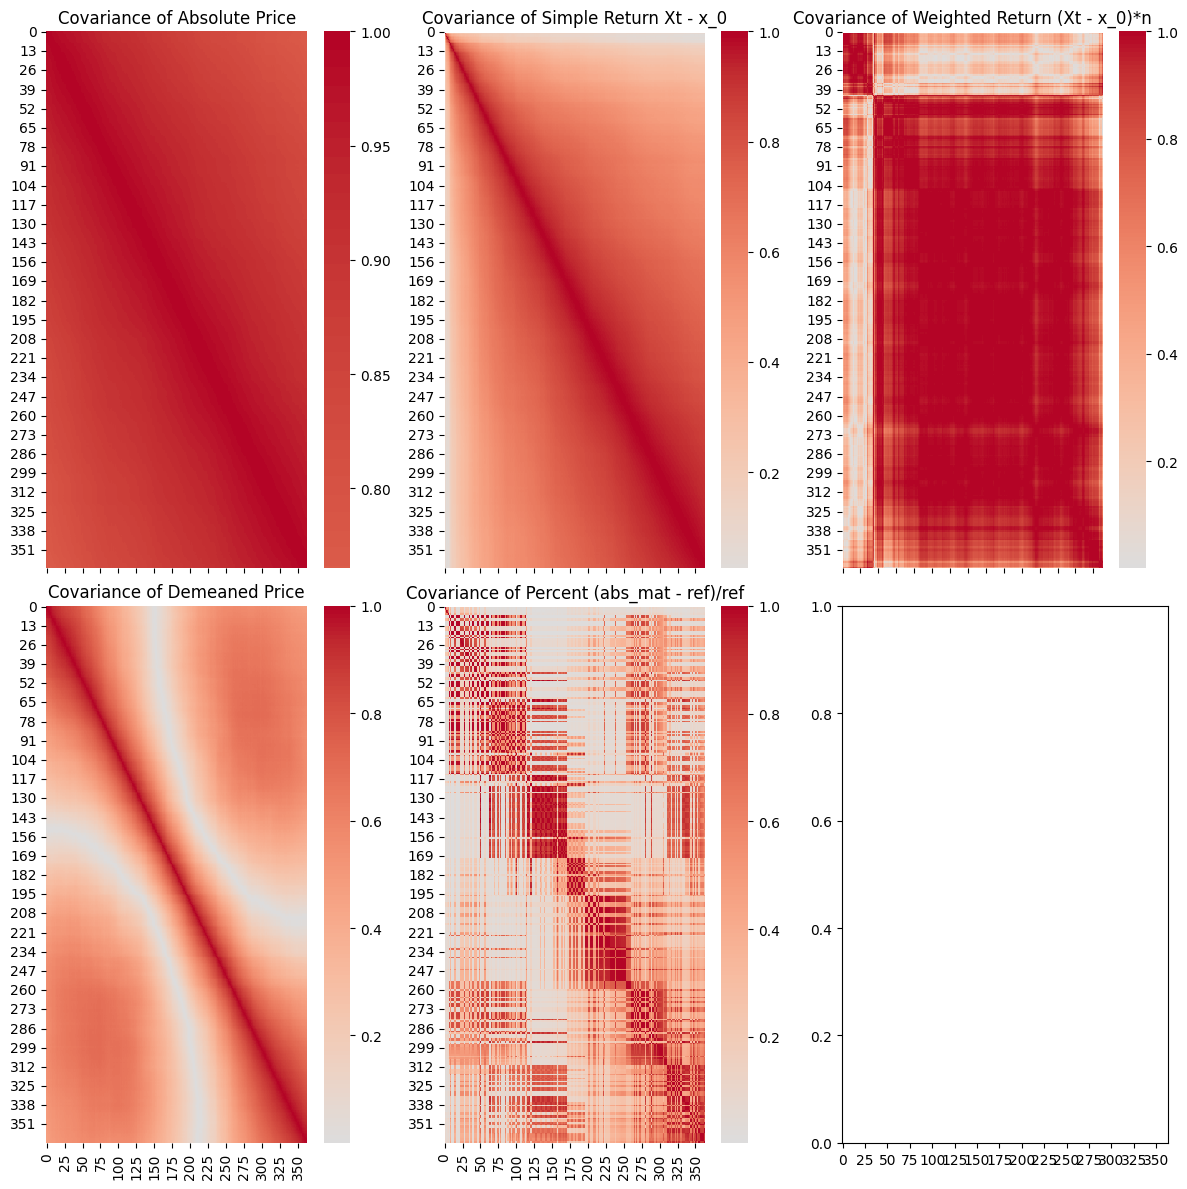

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# covariance matrix on absolute price, return per stock, absolute return weighted with amount of shares,  demeaned, percent
data = all_df_of_close_data.drop(columns=['Unnamed: 0.1', 'Unnamed: 0','issuer.name', 'issuer.tradingSymbol', 'reportingOwner.name', 'transactionDate', 'ownershipNature.directOrIndirectOwnership'])
def plot_heatmap(df, ax, plt_title = "Return Xt - x_0"):
    corr_matrix = df.corr(numeric_only=False).abs()
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=ax)
    ax.set_title(plt_title)    

day_cols = [str(i) for i in range(364)]
absolute_price_df = pd.DataFrame(all_df_of_close_data[day_cols])

# return per stock: returns for one share each filling
x_0 = data['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(0, 364)]
Xt = data[day_cols].to_numpy()
return_matrix = Xt - x_0
simple_return_df = pd.DataFrame(return_matrix)

# absolute return weighted with amount of shares
n = all_df_of_close_data['amounts.shares'].to_numpy()[:, None]
x_0 = all_df_of_close_data['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(0, 364)]
Xt = all_df_of_close_data[day_cols].to_numpy()
return_matrix = (Xt - x_0)*n
weighted_return_df = pd.DataFrame(return_matrix)

# demeaned
# with matrix or else warning
abs_mat = all_df_of_close_data[day_cols].to_numpy(dtype=float)
row_mean = np.nanmean(abs_mat, axis=1, keepdims=True)
demean_mat = abs_mat - row_mean
demean_df = pd.DataFrame(demean_mat)

#percent
# calculate percentage since day 0
ref = all_df_of_close_data[day_cols[0]].to_numpy(dtype=float)[:, None]
ref = np.where(ref == 0, np.nan, ref)
percent_mat = (abs_mat - ref) / ref
percent_df = pd.DataFrame(percent_mat)

# plot absolute, demeaned and percentage in one pic
fig, axs = plt.subplots(2, 3, figsize=(12, 12), sharex=True)

plot_heatmap(absolute_price_df,  axs[0, 0], "Covariance of Absolute Price")
plot_heatmap(simple_return_df,   axs[0, 1], "Covariance of Simple Return Xt - x_0")
plot_heatmap(weighted_return_df, axs[0, 2], "Covariance of Weighted Return (Xt - x_0)*n")
plot_heatmap(demean_df,          axs[1, 0], "Covariance of Demeaned Price")
plot_heatmap(percent_df,         axs[1, 1], "Covariance of Percent (abs_mat - ref)/ref")


plt.tight_layout()
#plt.savefig('exports/descriptive_random_state_69.png', dpi=500)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Load ---
df = pd.read_csv("data/all_df_of_close_data.csv")
day_cols = [c for c in df.columns if c.isdigit()]  # '0'..'363'

# --- Negative Werte entfernen (einmal, vektorisiert) ---
df[day_cols] = df[day_cols].mask(df[day_cols] < 0)



In [6]:

# --- IQR pro Spalte (einmal) + Outliers clippen statt Zeilen droppen ---
q = df[day_cols].quantile([0.25, 0.75], numeric_only=True)
q25, q75 = q.loc[0.25], q.loc[0.75]
upper = q75 + 1.5 * (q75 - q25)
df[day_cols] = df[day_cols].clip(upper=upper, axis=1)

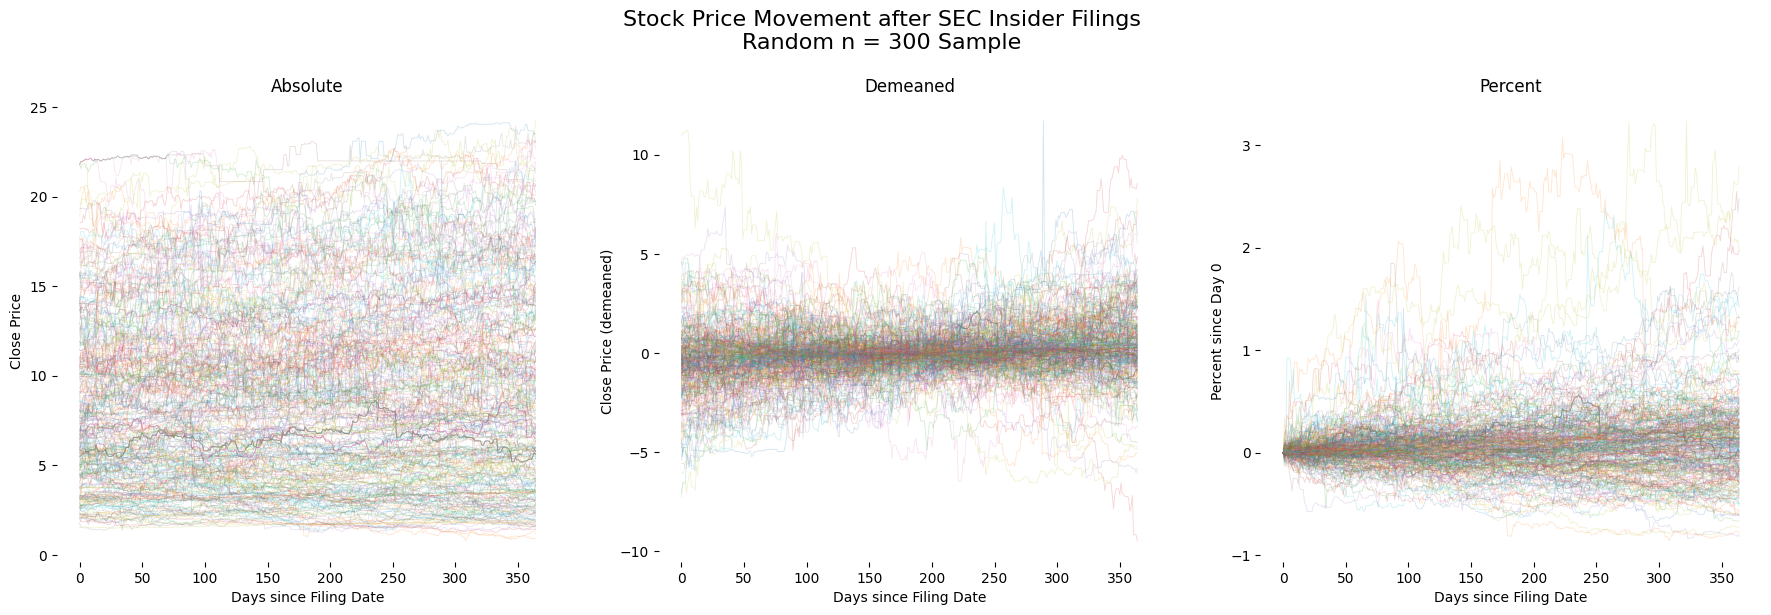

In [12]:

# --- Sample erst JETZT ziehen (macht alle Schritte vorher kleiner, wenn du willst, auch andersrum) ---
sample = df[day_cols].sample(n=min(300, len(df)), random_state=69)

# --- Matrices ---
abs_mat = sample.to_numpy(dtype=float)
row_mean = np.nanmean(abs_mat, axis=1, keepdims=True)
demean_mat = abs_mat - row_mean

ref = abs_mat[:, [0]]
ref = np.where(ref == 0, np.nan, ref)
percent_mat = (abs_mat - ref) / ref

x = np.arange(abs_mat.shape[1])

# --- Plot (rasterize für Speed) ---
fig, axs = plt.subplots(1, 3, figsize=(22, 6), sharex=True)

axs[0].plot(x, abs_mat.T, linewidth=0.6, alpha=0.2, rasterized=True)
axs[0].set_title('Absolute'); axs[0].set_xlabel('Days since Filing Date'); axs[0].set_ylabel('Close Price')

axs[1].plot(x, demean_mat.T, linewidth=0.6, alpha=0.2, rasterized=True)
axs[1].set_title('Demeaned'); axs[1].set_xlabel('Days since Filing Date'); axs[1].set_ylabel('Close Price (demeaned)')

axs[2].plot(x, percent_mat.T, linewidth=0.6, alpha=0.2, rasterized=True)
axs[2].set_title('Percent'); axs[2].set_xlabel('Days since Filing Date'); axs[2].set_ylabel('Percent since Day 0')

for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)

#plt.tight_layout()
fig.suptitle("Stock Price Movement after SEC Insider Filings\nRandom n = 300 Sample",
             fontsize=16, y=1.03)
plt.show()

